# 80 - Milestone Project: CIFAR-10

**Section:** CNN Milestone Projects | **Prereqs:** `CNN Milestone Projects/Fashion_MNIST.ipynb` | **Next:** `CNN Milestone Projects/CIFAR_10_AutoEncoder.ipynb`

Colour images, 10 object classes, 32x32. The step up from Fashion-MNIST is real:
3 input channels instead of 1, and the classes vary in pose, background, lighting
and scale rather than being centred silhouettes.

**Two things that must be right for colour data**
- `.permute(0,3,1,2)` converts numpy's `(N,H,W,C)` to PyTorch's `(N,C,H,W)`. Use
  `permute`, never `view` - `view` would reinterpret the memory and scramble
  every image while raising no error.
- `/ 255.` scales to [0,1]. Per-channel `Normalize` with the dataset's mean and
  std is better still (see `CNNs/CNN_CIFAR_100.ipynb`).

**No augmentation here**, which is the main thing separating this from the
CIFAR-100 notebook's recipe. On CIFAR, random crop plus horizontal flip is worth
several points of accuracy on its own - it is the single highest-value addition
to this notebook.

**Expected result:** roughly 75-85% without augmentation. The confusion matrix
will show cat/dog as the hardest pair, and the animal classes generally harder
than the vehicles.

In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from torchsummary import summary
from torchvision.datasets import CIFAR10

from sklearn.model_selection import train_test_split

In [121]:
# CIFAR-10: 50000 train, 10000 test, 32x32 RGB, 10 classes.
train = CIFAR10(root = '/', train=True, download=True)
test = CIFAR10(root='/', train=False, download=True)

In [122]:
train_data = train.data
train_label = train.targets

test_data = test.data
test_label = test.targets

In [123]:
# Class names in label order.
categories = train.classes

In [124]:
categories

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [125]:
# The crucial line: .permute(0,3,1,2) converts (N,H,W,C) to (N,C,H,W).
# permute REORDERS axes; view would reinterpret raw memory and silently scramble
# every image. This is the most common CIFAR bug.
# /255. scales to [0,1]. Per-channel Normalize would be better still.
# 80/20 train/validation split, with the official test set kept separate.
device = ('cuda' if torch.cuda.is_available() else 'cpu')

train_data, val_data , train_label , val_label = train_test_split(train_data, train_label, train_size=0.80)

train_dataset = TensorDataset(torch.tensor(train_data, dtype=torch.float,device=device).permute(0, 3, 1, 2) / 255., torch.tensor(train_label, dtype=torch.long,device=device))
val_dataset = TensorDataset(torch.tensor(val_data, dtype=torch.float,device=device).permute(0, 3, 1, 2) / 255., torch.tensor(val_label, dtype=torch.long,device=device))

test_dataset = TensorDataset(torch.tensor(test_data, dtype=torch.float,device=device).permute(0, 3, 1, 2) / 255., torch.tensor(test_label, dtype=torch.long,device=device))

In [126]:
val_dataset.tensors[0].shape ,  device

(torch.Size([10000, 3, 32, 32]), 'cuda')

In [127]:
# Loaders. (shuffle=True on the validation and test loaders is unnecessary -
# order is irrelevant when no gradients are computed.)
# DataLoaders

bs = 256

train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=val_dataset.tensors[0].shape[0])
test_loader = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0])

### Model Defination

In [128]:
# The same architecture as the Fashion-MNIST notebook, with 3 input channels and
# a 4x4 feature map before the flatten (32 -> 16 -> 8 -> 4).
class CNNModel(nn.Module):
  def __init__(self, chan_num, linear_num ) -> None:
    super().__init__()

    self.layers = nn.Sequential(
        nn.Conv2d(3,chan_num, kernel_size=3, padding=1,stride=1), # Output -> [6,32,32]
        nn.BatchNorm2d(chan_num),
        nn.LeakyReLU(),
        nn.AvgPool2d(2,2), # Output -> [6,16,16]

        nn.Conv2d(chan_num,2*chan_num, kernel_size=3, padding=1,stride=1), # Output -> [12,16,16]
        nn.BatchNorm2d(2*chan_num),
        nn.LeakyReLU(),
        nn.AvgPool2d(2,2), # Output -> [12,8,8]

        nn.Conv2d(2*chan_num,4*chan_num, kernel_size=3, padding=1,stride=1), # Output -> [12,8,8]
        nn.BatchNorm2d(4*chan_num),
        nn.LeakyReLU(),
        nn.AvgPool2d(2,2), # Output -> [12,4,4]


        # nn.AdaptiveAvgPool2d(1),
        nn.Flatten(),
        nn.Linear(4*chan_num*4*4, linear_num),
        nn.Dropout(p=0.5),
        # nn.BatchNorm1d(linear_num),
        nn.ReLU(),
        nn.Linear(linear_num,linear_num),
        nn.Dropout(p=0.5),
        nn.Linear(linear_num,10)


    )


  def forward(self,x):
    return self.layers(x)

In [129]:
test_model = CNNModel(64,256).to(device)

In [130]:
# torchsummary at width 64.
summary(test_model, input_size=(3,32,32), batch_size=128)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [128, 64, 32, 32]           1,792
       BatchNorm2d-2          [128, 64, 32, 32]             128
         LeakyReLU-3          [128, 64, 32, 32]               0
         AvgPool2d-4          [128, 64, 16, 16]               0
            Conv2d-5         [128, 128, 16, 16]          73,856
       BatchNorm2d-6         [128, 128, 16, 16]             256
         LeakyReLU-7         [128, 128, 16, 16]               0
         AvgPool2d-8           [128, 128, 8, 8]               0
            Conv2d-9           [128, 256, 8, 8]         295,168
      BatchNorm2d-10           [128, 256, 8, 8]             512
        LeakyReLU-11           [128, 256, 8, 8]               0
        AvgPool2d-12           [128, 256, 4, 4]               0
          Flatten-13                [128, 4096]               0
           Linear-14                 [1

In [132]:
# The full regularisation stack used in these milestone projects:
#   Adam with weight_decay=5e-4  (L2),
#   an explicit L1 penalty normalised by the parameter count,
#   Dropout(0.5) between the fully connected layers,
#   BatchNorm after every convolution.
# Four regularisers at once is more than most models need. If the model is
# UNDERfitting (train accuracy low), remove some before adding capacity - see
# Regularization/Dropuout.ipynb for what over-regularisation looks like.
# Note the L1 sum runs over every parameter including biases and BatchNorm
# scales; weights only is the textbook form.
def train_model(chan_num, linear_num):

  model = CNNModel(chan_num, linear_num).to(device)

  lossfunc = nn.CrossEntropyLoss()
  epochs = 50
  optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=5e-4,
    betas=(0.9, 0.999)
)


  losses = []
  train_acc = []
  val_acc = []

  l1_lambda = 5e-4

  for epoch in range(epochs):

    model.train()

    batch_acc = []
    batch_loss = []

    for x,y in train_loader:

      yhat = model(x)

      loss = lossfunc(yhat,y)

      # Calculate L1 norm and normalize by the number of parameters
      l1_norm = sum(p.abs().sum() for p in model.parameters())
      num_parameters = sum(p.numel() for p in model.parameters())
      loss = loss + l1_lambda * (l1_norm / num_parameters)

      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      acc = 100 * torch.mean( (torch.argmax(yhat, dim=1) == y).float().detach().cpu())
      batch_acc.append(acc)

    losses.append(np.mean(batch_loss))
    train_acc.append(np.mean(batch_acc))

    # Now validation

    model.eval()
    with torch.no_grad():
      X,Y = next(iter(val_loader))
      X = X.to(device)
      Y = Y.to(device)
      val_acc.append( 100 * torch.mean( (torch.argmax(model(X), dim=1) == Y).float().detach().cpu()) )


    if epoch % 10 == 0 or epoch == epochs-1 :
      print(f'Epoch {epoch} | Loss : {losses[epoch]:.4f} | Train Acc {train_acc[epoch]} | Val Acc : {val_acc[epoch]}')

  return model, losses, train_acc, val_acc

In [133]:
# Train at chan_num=256, linear_num=512.
model, losses, train_acc, val_acc = train_model(256,512)

Epoch 0 | Loss : 1.5586 | Train Acc 43.09066390991211 | Val Acc : 52.82999801635742
Epoch 10 | Loss : 0.5350 | Train Acc 81.18282318115234 | Val Acc : 77.10000610351562
Epoch 20 | Loss : 0.2673 | Train Acc 90.62002563476562 | Val Acc : 79.61000061035156
Epoch 30 | Loss : 0.1313 | Train Acc 95.32743072509766 | Val Acc : 79.00999450683594
Epoch 40 | Loss : 0.0867 | Train Acc 97.1238021850586 | Val Acc : 79.63999938964844
Epoch 49 | Loss : 0.0672 | Train Acc 97.70352172851562 | Val Acc : 80.62000274658203


In [134]:
# Evaluation on the untouched test set.
with torch.no_grad():
      X,Y = next(iter(test_loader))
      X = X.to(device)
      Y = Y.to(device)
      preds = torch.argmax(model(X), dim=1)
      val_acc = (100 * torch.mean((preds == Y).float()).detach().cpu())

In [135]:
# Test accuracy. Chance is 10%; 75-85% is the range to expect without
# augmentation.
val_acc

tensor(80.7400)

In [136]:
# Per-class report. sklearn's signature is (y_true, y_pred) - reversing it swaps
# precision and recall silently, since both arguments are just label arrays.
from sklearn.metrics import classification_report, confusion_matrix
report = classification_report(Y.detach().cpu().numpy(), preds.detach().cpu().numpy(), target_names=categories)
print(report)

              precision    recall  f1-score   support

           0       0.90      0.76      0.82      1171
           1       0.91      0.90      0.91      1015
           2       0.79      0.67      0.72      1176
           3       0.70      0.63      0.67      1117
           4       0.78      0.79      0.78       988
           5       0.60      0.84      0.70       712
           6       0.84      0.89      0.86       945
           7       0.87      0.82      0.85      1065
           8       0.85      0.94      0.89       902
           9       0.84      0.93      0.88       909

    accuracy                           0.81     10000
   macro avg       0.81      0.82      0.81     10000
weighted avg       0.81      0.81      0.81     10000



In [137]:
c_matrix = confusion_matrix(Y.detach().cpu().numpy(), preds.detach().cpu().numpy())

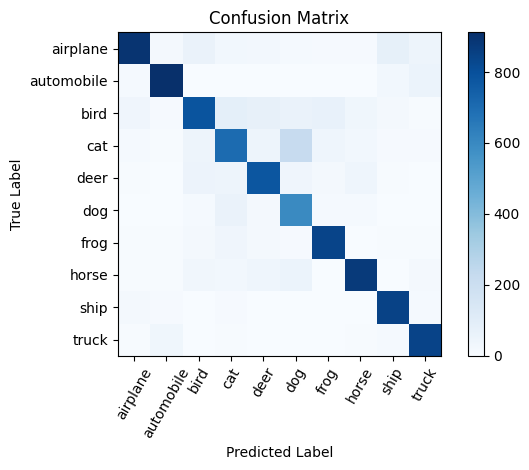

In [138]:
# The confusion matrix. Expect cat/dog to be the brightest off-diagonal pair,
# and the vehicle classes to be cleaner than the animals - vehicles have rigid
# shapes, animals do not.
plt.imshow(c_matrix, cmap='Blues')
plt.xticks(range(len(categories)), categories, rotation=60)
plt.yticks(range(len(categories)), categories)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.colorbar()
plt.tight_layout()
plt.show()

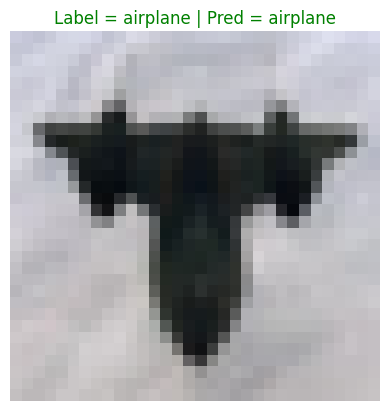

In [154]:
# One test image with its true and predicted label.
# .permute(1,2,0) converts back to (H,W,C) for matplotlib - the inverse of the
# conversion in the data cell.
# The title is green when the prediction is right and red when it is wrong -
# a hardcoded colour would claim success on every image.
plt.imshow(X[0].permute(1,2,0).detach().cpu().numpy());
plt.title(f'Label = {categories[Y[0].item()]} | Pred = {categories[preds[0].item()]}',
          color = 'green' if Y[0].item() == preds[0].item() else 'red');
plt.axis('off');

In [148]:
categories[Y[0].item()]

'airplane'